In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib, json, sklearn
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

df = pd.read_csv("../Data/solar_clean.csv", parse_dates=['Date-Hour(NMT)'])
df['Hour']  = df['Date-Hour(NMT)'].dt.hour
df['Month'] = df['Date-Hour(NMT)'].dt.month
print(len(df), "rows")



8256 rows


In [5]:
FEATURES = ['WindSpeed','Sunshine','AirPressure','Radiation','AirTemperature',
            'RelativeAirHumidity']
X, y = df[FEATURES], df['SystemProduction']

In [6]:
tscv = TimeSeriesSplit(n_splits=5)

def cv_score(model, X, y):
    rows = []
    for tr, te in tscv.split(X):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        p = np.clip(m.predict(X.iloc[te]), 0, None)
        rows.append({'mae':  mean_absolute_error(y.iloc[te], p),
                     'rmse': np.sqrt(mean_squared_error(y.iloc[te], p)),
                     'r2':   r2_score(y.iloc[te], p)})
    return pd.DataFrame(rows).mean().round(3)

In [7]:

results = pd.DataFrame({
    'Mean baseline':     cv_score(DummyRegressor(strategy='mean'), X, y),
    'Linear Regression': cv_score(LinearRegression(), X, y),
    'Random Forest':     cv_score(RandomForestRegressor(
                             n_estimators=300, min_samples_leaf=2,
                             random_state=42, n_jobs=-1), X, y),
}).T
results

,mae,rmse,r2
Mean baseline,1120.826,1629.806,-2.824
Linear Regression,515.372,891.365,0.493
Random Forest,470.700,886.419,0.524


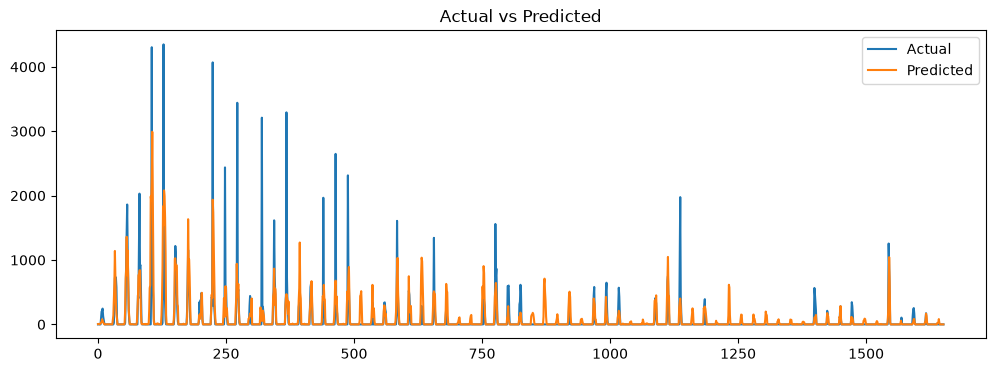

In [8]:
si = int(len(df) * 0.8)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                           random_state=42, n_jobs=-1).fit(X[:si], y[:si])
pred = np.clip(rf.predict(X[si:]), 0, None)

plt.figure(figsize=(12,4))
plt.plot(y[si:].values, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend(); plt.title('Actual vs Predicted'); plt.show()

In [9]:
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators':[200,300,400], 'max_depth':[12,16,20,None],
     'min_samples_leaf':[1,2,5,10], 'max_features':[0.4,0.6,0.8,1.0]},
    n_iter=20, scoring='neg_mean_absolute_error',
    cv=tscv, random_state=42, n_jobs=-1)

search.fit(X, y)
print(search.best_params_, "| CV MAE:", round(-search.best_score_, 1))

{'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 0.8, 'max_depth': 16} | CV MAE: 462.7


In [10]:
out = Path("../models/v2"); out.mkdir(parents=True, exist_ok=True)
joblib.dump(search.best_estimator_, out/"model.pkl", compress=3)
json.dump({"features": FEATURES, "target": "SystemProduction", "unit": "Wh",
           "cv_mae": round(-search.best_score_, 2), "n_rows": len(X),
           "seed": 42, "sklearn": sklearn.__version__},
          open(out/"metadata.json","w"), indent=2)
print("saved:", round((out/"model.pkl").stat().st_size/1e6, 1), "MB")

saved: 4.8 MB


In [11]:
import json
from pathlib import Path

v1 = json.load(open("../models/v1/metadata.json"))
v2 = json.load(open("../models/v2/metadata.json"))

json.dump({
    "promoted": "v2",
    "versions": {
        "v1": {"cv_mae": v1["cv_mae"], "note": "raw data, no cleaning, no tuning"},
        "v2": {"cv_mae": v2["cv_mae"], "note": "cleaned data, tuned"}
    }
}, open("../models/registry.json", "w"), indent=2)

print(open("../models/registry.json").read())

{
  "promoted": "v2",
  "versions": {
    "v1": {
      "cv_mae": 476.94,
      "note": "raw data, no cleaning, no tuning"
    },
    "v2": {
      "cv_mae": 462.74,
      "note": "cleaned data, tuned"
    }
  }
}


In [12]:
# v1 
raw = pd.read_csv("../Data/Solar Power Plant Data.csv")
raw['Date-Hour(NMT)'] = pd.to_datetime(raw['Date-Hour(NMT)'], format='%d.%m.%Y-%H:%M')
raw['Hour']  = raw['Date-Hour(NMT)'].dt.hour
raw['Month'] = raw['Date-Hour(NMT)'].dt.month

FEATURES_V1 = ['WindSpeed','Sunshine','AirPressure','Radiation',
               'AirTemperature','RelativeAirHumidity','Hour','Month']
X1, y1 = raw[FEATURES_V1], raw['SystemProduction']

model_v1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X1, y1)
mae_v1 = cv_score(model_v1, X1, y1)['mae']

out1 = Path("../models/v1"); out1.mkdir(parents=True, exist_ok=True)
joblib.dump(model_v1, out1/"model.pkl", compress=3)
json.dump({"features": FEATURES_V1, "target": "SystemProduction", "unit": "Wh",
           "cv_mae": round(mae_v1, 2), "n_rows": len(X1), "seed": 42,
           "sklearn": sklearn.__version__, "note": "raw data, no cleaning, no tuning"},
          open(out1/"metadata.json", "w"), indent=2)

print("v1 CV MAE:", round(mae_v1, 1))

v1 CV MAE: 476.9
